In [54]:
import torch
from torch.optim import Adam
import torch.nn.functional as F
from tqdm.auto import trange
import numpy as np
import matplotlib.pyplot as plt
from dgl.dataloading import GraphDataLoader
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning import Trainer
import pandas as pd
import dgl

from gnncloudmanufacturing.data import sample_dataset
from gnncloudmanufacturing.validation import check_feasibility, total_cost_from_gamma
from gnncloudmanufacturing.utils import (
    graph_from_problem, os_type, ss_type, GraphDataset, gamma_from_target, delta_from_gamma)
from gnncloudmanufacturing.graph_model import GNN

In [18]:
n_tasks, n_operations, n_cities = 5, 5, 5
dirpath = dirpath = f'train_data/{n_tasks}-{n_operations}-{n_cities}/'
dataset = sample_dataset(
    100, 
    [n_tasks, n_tasks],
    [n_operations, n_operations],
    [n_cities, n_cities],
    threshold=0.2,
    dirpath=dirpath,
    random_seed=0
)

In [19]:
train_dataset = dataset[:80]
val_dataset = dataset[80:]

In [20]:
for problem in train_dataset:
    name = problem['name']
    delta = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/delta.npy')
    gamma = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/gamma.npy')
    check_feasibility(gamma, delta, problem)
    total_cost = total_cost_from_gamma(problem, gamma, delta)
    print(f'Problem {problem["name"]}: {total_cost:.2f}')

Problem 5,5,5-1: 5850.45
Problem 5,5,5-2: 6225.56
Problem 5,5,5-3: 5433.76
Problem 5,5,5-4: 7654.05
Problem 5,5,5-5: 6821.67
Problem 5,5,5-6: 4493.18
Problem 5,5,5-7: 6225.56
Problem 5,5,5-8: 6542.59
Problem 5,5,5-9: 5344.09
Problem 5,5,5-10: 6451.34
Problem 5,5,5-11: 5623.14
Problem 5,5,5-12: 5106.74
Problem 5,5,5-13: 5498.16
Problem 5,5,5-14: 7100.71
Problem 5,5,5-15: 5299.21
Problem 5,5,5-16: 4623.48
Problem 5,5,5-17: 6935.02
Problem 5,5,5-18: 6680.80
Problem 5,5,5-19: 6891.38
Problem 5,5,5-20: 6313.17
Problem 5,5,5-21: 6083.14
Problem 5,5,5-22: 6210.28
Problem 5,5,5-23: 6494.11
Problem 5,5,5-24: 7055.82
Problem 5,5,5-25: 6014.06
Problem 5,5,5-26: 6391.26
Problem 5,5,5-27: 5386.87
Problem 5,5,5-28: 5241.82
Problem 5,5,5-29: 5158.90
Problem 5,5,5-30: 6944.59
Problem 5,5,5-31: 6020.93
Problem 5,5,5-32: 5895.31
Problem 5,5,5-33: 5962.33
Problem 5,5,5-34: 6018.29
Problem 5,5,5-35: 7477.86
Problem 5,5,5-36: 6396.04
Problem 5,5,5-37: 5549.84
Problem 5,5,5-38: 6180.67
Problem 5,5,5-39: 652

In [21]:
average_cost = 0
for problem in val_dataset:
    name = problem['name']
    delta = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/delta.npy')
    gamma = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/gamma.npy')
    check_feasibility(gamma, delta, problem)
    total_cost = total_cost_from_gamma(problem, gamma, delta)
    average_cost += total_cost
    print(f'Problem {problem["name"]}: {total_cost:.2f}')
average_cost = average_cost / len(val_dataset)
print(f'Average cost: {average_cost:.2f}')

Problem 5,5,5-81: 5944.42
Problem 5,5,5-82: 5516.11
Problem 5,5,5-83: 7399.83
Problem 5,5,5-84: 6670.25
Problem 5,5,5-85: 6451.34
Problem 5,5,5-86: 6366.44
Problem 5,5,5-87: 6313.17
Problem 5,5,5-88: 6303.60
Problem 5,5,5-89: 6040.37
Problem 5,5,5-90: 6899.70
Problem 5,5,5-91: 6881.75
Problem 5,5,5-92: 6899.70
Problem 5,5,5-93: 5167.91
Problem 5,5,5-94: 7075.89
Problem 5,5,5-95: 5980.91
Problem 5,5,5-96: 5199.04
Problem 5,5,5-97: 5350.38
Problem 5,5,5-98: 5717.06
Problem 5,5,5-99: 6225.56
Problem 5,5,5-100: 6944.59
Average cost: 6267.40


In [22]:
max_operations = 5

train_graphs = []
for problem in train_dataset:
    name = problem['name']
    gamma = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/gamma.npy')
    graph = graph_from_problem(problem, gamma, max_operations=max_operations)
    graph.edata['feat'][os_type][:, 0] /= 10
    graph.edata['feat'][ss_type][:] /= 100
    train_graphs.append(graph)

val_graphs = []
for problem in val_dataset:
    name = problem['name']
    gamma = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/gamma.npy')
    graph = graph_from_problem(problem, gamma, max_operations=max_operations)
    graph.edata['feat'][os_type][:, 0] /= 10
    graph.edata['feat'][ss_type][:] /= 100
    val_graphs.append(graph)

In [28]:
train_graph_dataset = GraphDataset(train_graphs)
val_graph_dataset = GraphDataset(val_graphs)

In [29]:
train_dataloader = GraphDataLoader(train_graph_dataset, batch_size=8, shuffle=True)
val_dataloader = GraphDataLoader(val_graph_dataset, batch_size=100)

In [78]:
model = GNN(
    ins_dim=1,
    ino_dim=max_operations,
    out_dim=16,
    n_layers=1,
    lr=0.002,
)
model

GNN(
  (convs): ModuleList(
    (0): AttnConvLayer(
      (W_s): Linear(in_features=1, out_features=16, bias=True)
      (W_os): Linear(in_features=7, out_features=16, bias=True)
      (W_ss): Linear(in_features=2, out_features=16, bias=True)
      (attn): Linear(in_features=32, out_features=1, bias=True)
      (W_in): Linear(in_features=5, out_features=16, bias=True)
      (W_self): Linear(in_features=5, out_features=16, bias=True)
      (W_out): Linear(in_features=5, out_features=16, bias=True)
      (W_o): Linear(in_features=48, out_features=16, bias=True)
    )
  )
  (dropout): Dropout(p=0.0, inplace=False)
  (dec): DotProductDecoder()
)

In [79]:
trainer = Trainer(
    enable_progress_bar=True,
    max_epochs=200,
    log_every_n_steps=1,
    logger=CSVLogger('.'),
    accelerator='cpu',
)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


In [80]:
trainer.fit(
    model=model, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)


  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | convs   | ModuleList        | 1.3 K  | train
1 | dropout | Dropout           | 0      | train
2 | dec     | DotProductDecoder | 0      | train
------------------------------------------------------
1.3 K     Trainable params
0         Non-trainable params
1.3 K     Total params
0.005     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                           |…

/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                                  |…

Validation: |                                                                                                |…

...

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

`Trainer.fit` stopped: `max_epochs=200` reached.


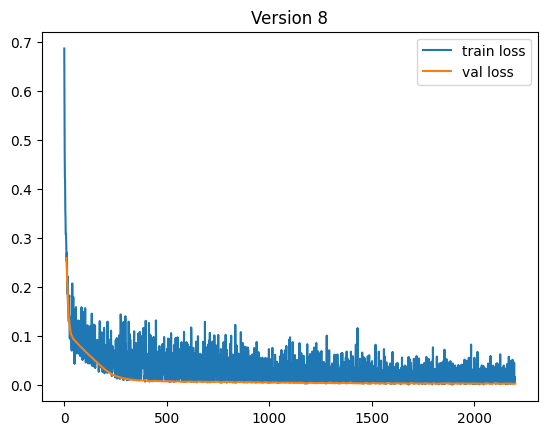

In [81]:
metrics = pd.read_csv(f'lightning_logs/version_{trainer.logger.version}/metrics.csv')
plt.plot(metrics.train_loss.dropna(), label='train loss')
plt.plot(metrics.val_loss.dropna(), label='val loss')
plt.legend()
plt.title(f'Version {trainer.logger.version}')
plt.show()

In [148]:
average_cost = 0
for problem in val_dataset:
    name = problem['name']
    graph = graph_from_problem(problem, max_operations=max_operations)
    graph.edata['feat'][os_type][:, 0] /= 10
    graph.edata['feat'][ss_type][:] /= 100
    pred = model.predict(graph)
    gamma = gamma_from_target(pred, graph, problem)
    delta = delta_from_gamma(problem, gamma)
    check_feasibility(gamma, delta, problem)
    total_cost = total_cost_from_gamma(problem, gamma, delta)
    average_cost += total_cost
    print(f'Problem {problem["name"]}: {total_cost:.2f}')
average_cost = average_cost / len(val_dataset)
print(f'Average cost: {average_cost:.2f}')

Problem 5,5,5-81: 5944.42
Problem 5,5,5-82: 5516.11
Problem 5,5,5-83: 7399.83
Problem 5,5,5-84: 6670.25
Problem 5,5,5-85: 6451.34
Problem 5,5,5-86: 6366.44
Problem 5,5,5-87: 6313.17
Problem 5,5,5-88: 6303.60
Problem 5,5,5-89: 6373.01
Problem 5,5,5-90: 6899.70
Problem 5,5,5-91: 6881.75
Problem 5,5,5-92: 6899.70
Problem 5,5,5-93: 5167.91
Problem 5,5,5-94: 7075.89
Problem 5,5,5-95: 5980.91
Problem 5,5,5-96: 5199.04
Problem 5,5,5-97: 5350.38
Problem 5,5,5-98: 5717.06
Problem 5,5,5-99: 6700.87
Problem 5,5,5-100: 6944.59
Average cost: 6307.80
